# Modelagem do modelo do Poço Duplo Finito

## Introdução ao potencial do Poço Duplo Finito

O poço duplo finito representa uma molécula de $\mathrm H_2^{+}$, usado para modelar o confinamento de um elétron nessa molécula diatômica [1]. Ele consiste em um potencial que tem o valor $V_0$ constante para todo $x$, exceto por dois trechos nos quais possui valor zero, como mostra a seguir.

<center> 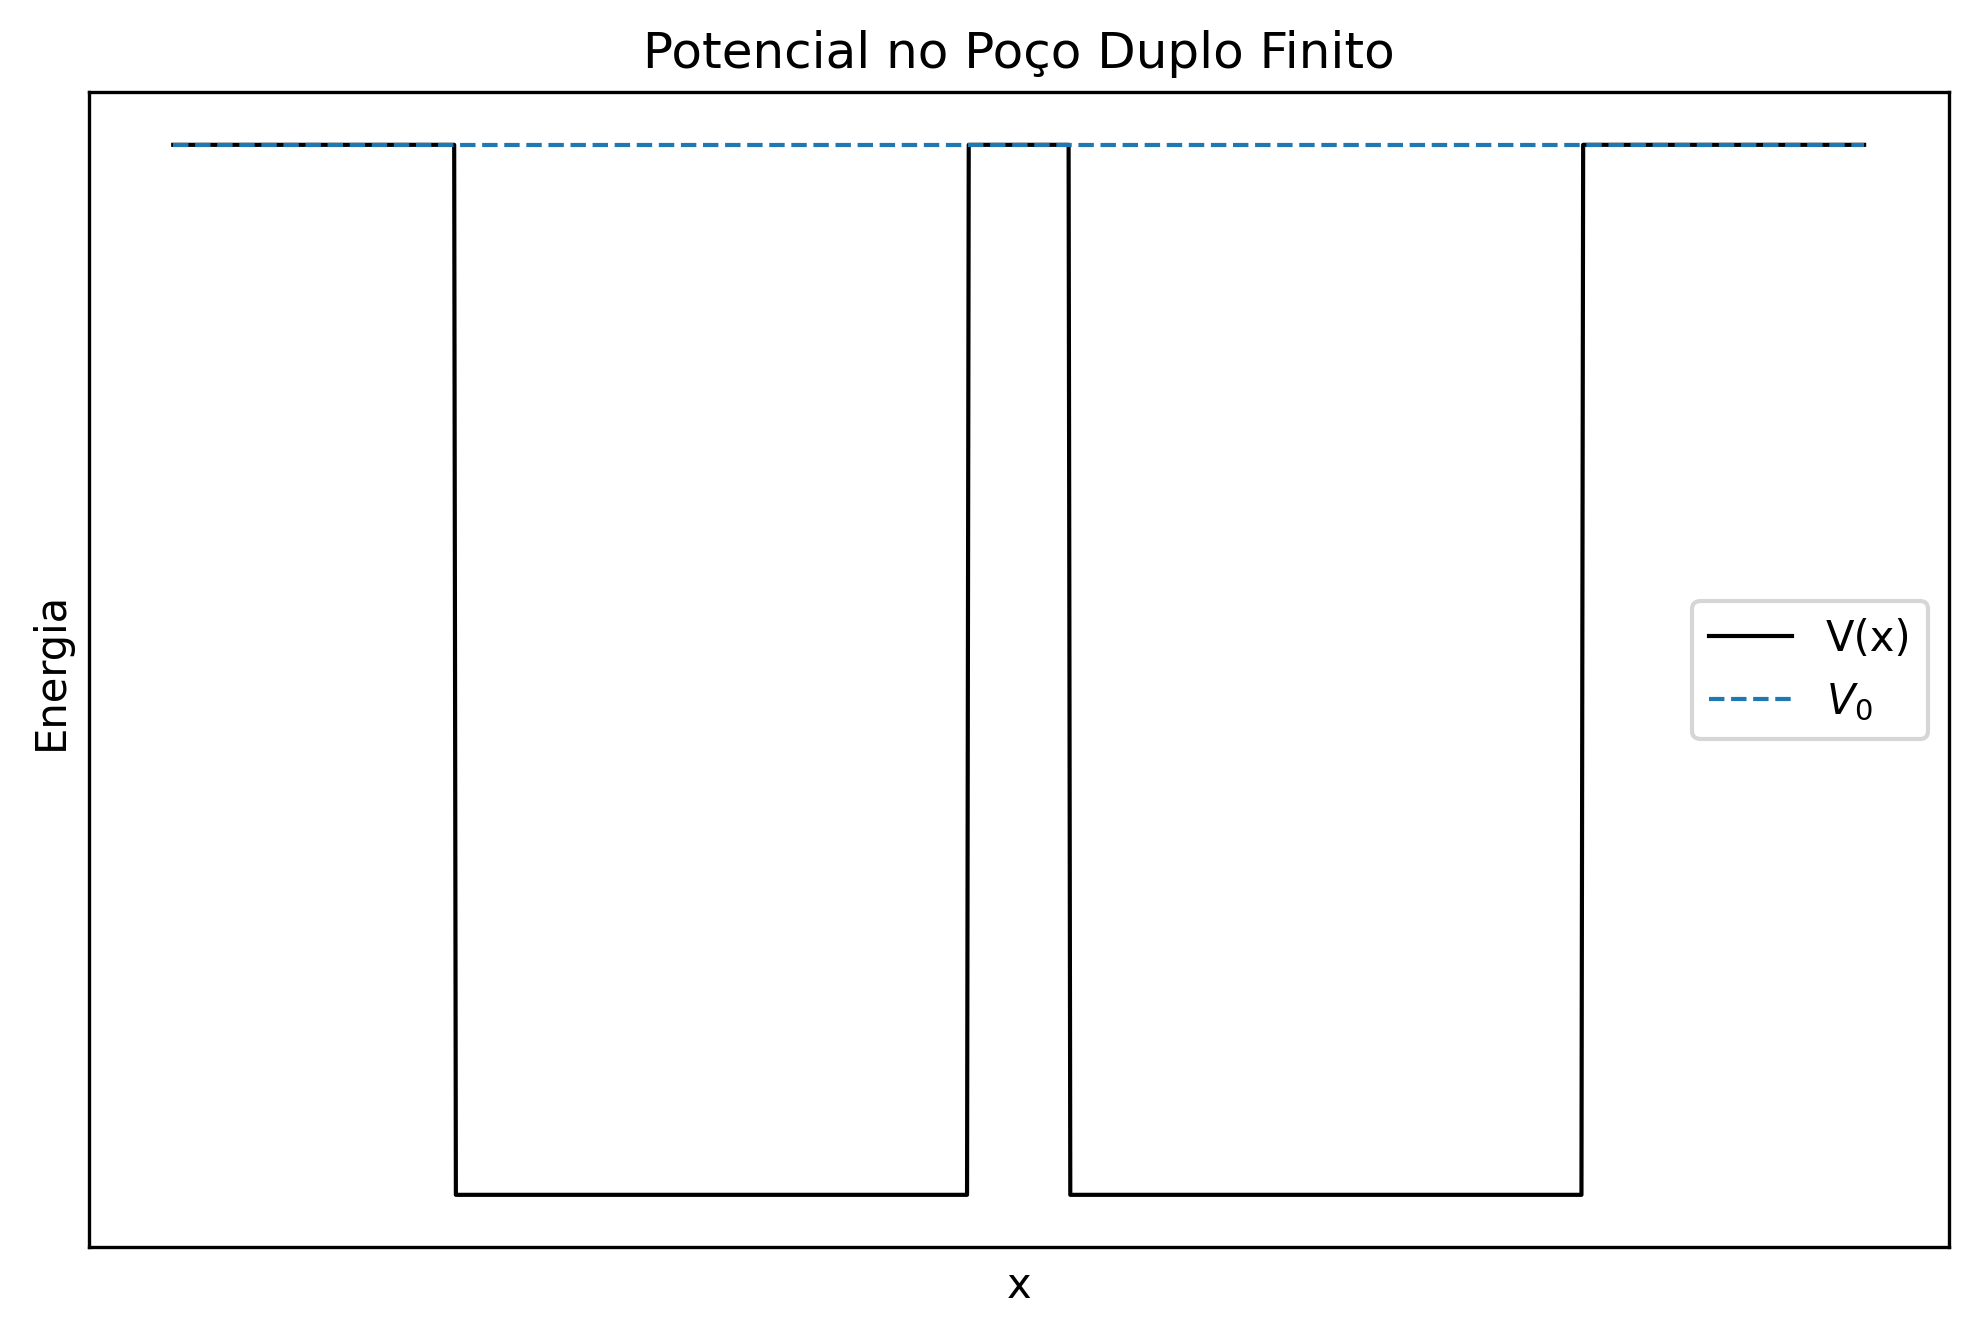 <center>
<center> Figura 1: Potencial no modelo de Poço Duplo Finito. <center>

## Importações

In [8]:
from scipy.sparse.linalg import eigs
from scipy import sparse

import matplotlib.pyplot as plt
import numpy as np

## Definição de constantes e parâmetros

Além de constantes físicas (massa do elétron, constante de Planck reduzida e elétron-volt), são definidos parâmetros para a modelagem, são eles:

 - `L`: largura do poço;
 - `d_pocos`: distância entre os poços (função de L);
 - `V0`: altura das barreiras (acima dessa energia o elétron não estará mais confinado);
 - `num_estados`: número de estados calculados (n primeiros);
 - `N`: número de pontos na malha para cálculo por diferenças finitas.

Além desses, a malha (`X`) é definida. O array do potencial (`V`) também é definido, possui valor $V_0$ para todos os pontos exceto nos intervalos $(-\frac{d}{2}+L, -\frac{d}{2})$ e $(\frac{d}{2}, \frac{d}{2}+L)$.

In [4]:
# Constantes físicas 
m = 9.11e-31       # Massa elétron (kg)
hbar = 1.054e-34   # Constante de Planck Reduzida (J.s)
eV = 1.602e-19     # 1 elétron-volt (J)

# Parâmetros para modelagem
L = 2.5e-9         # Largura do poço
d_pocos = L/5      # Distância entre os poços em função da largura L
V0 = 0.35 * eV     # Altura das barreiras
num_estados = 6    # Número de estados calculados
N = 1000           # Número de pontos da malha

# Malha
X = np.linspace(-1.5*((d_pocos/2) + L), 1.5*((d_pocos/2) + L), N)  # eixo x expandido para mostrar além do poço

# Potencial
def V(X_, v0, d):
    V = []
    for x_ in X_:
        if x_ <= -((d/2) + L):            # Intervalo até barreira esquerda do poço esquerdo
            V.append(v0)
        elif -((d/2) + L) < x_ < -(d/2):  # Intervalo do poço esquerdo
            V.append(0)
        elif -(d/2) <= x_ <= (d/2):       # Intervalo entre poços
            V.append(v0)
        elif (d/2) < x_ < ((d/2) + L):    # Intervalo do poço direito
            V.append(0)
        elif x_ >= ((d/2) + L):           # Intervalo para além da barreira direita do poço direito
            V.append(v0)
    return np.array(V)
V = V(x, V0, d_pocos)

## Visualizando o potencial

Com os parâmetros para o modelo definidos, é possível mostrar exatamente o potencial estudado. Abaixo está um código que constrói o plot do potencial.

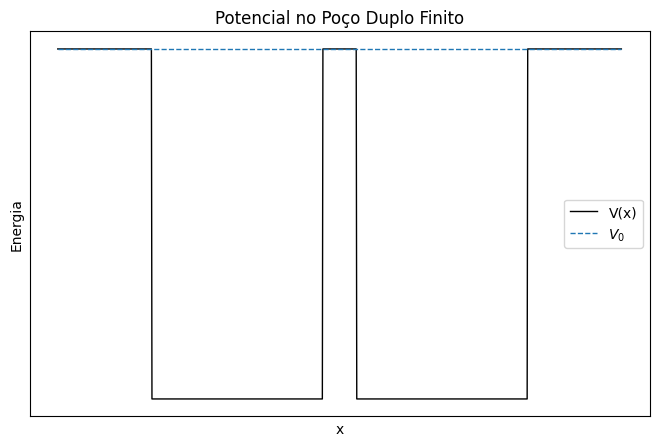

In [5]:
# ------------------- PLOT: Potencial -------------------
plt.figure(figsize=(8, 5))

# Potencial do poço
plt.plot(x*1e9, V/eV, 'k-', linewidth=1, label='V(x)')
plt.plot(x*1e9, [V0/eV]*len(x), linestyle='--', linewidth=1, label='$V_0$')

plt.xlabel('x')
plt.ylabel('Energia')
plt.title('Potencial no Poço Duplo Finito')
plt.legend(loc='center right')

# Omitindo valores nos eixos
plt.xticks([])   # remove números do eixo x
plt.yticks([])   # remove números do eixo y

# Salvar figura 
plt.savefig("Resultados/potencial_duplo_poco.png", dpi=300, bbox_inches='tight')

plt.show()

## Modelagem via Diferenças Finitas

O método das Diferenças Finitas oferece uma aproximação para as derivadas de segunda ordem e permite que a equação diferencial seja representada por matrizes. A primeira etapa da modelagem, portanto, foi aplicar o método à Equação de Schrödinger unidimensional e independente do tempo. Ou seja, aplicá-lo a seguinte equação:

$$
-\frac{\hbar^{2}}{2m}\,\frac{\mathrm d^2\, \psi(x)}{\mathrm d x^2} + V(x)\,\psi(x) = \mathrm E \, \psi(x)
$$

Pelo método das diferenças finitas, a aproximação para a derivada de segunda ordem é: 
 
$$
\frac{X_{i-1} - 2X_{i} + X_{i+1}}{\ell^2}
$$

Assim, a Equação de Schrödinger pode ser escrita como: 

$$
-\frac{\hbar^2}{2m}\bigg[\frac{\psi_{i-1} - 2\psi_{i} + \psi_{i+1}}{\ell^2}\bigg] + V(x) \psi_i = E\psi_i 
$$

Essa equação representa um sistema linear de equações, o qual pode ser reescrito na forma matricial, caso em que o Hamiltoniano assume a forma

$$
\hat{H}_{df}=
-\frac{\hbar^2}{2m\ell^2}
\begin{bmatrix}
-2 & 1 & 0 & \cdots & 0 \\
1 & -2 & 1 & \cdots & 0 \\
0 & 1 & -2 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & 1 & -2
\end{bmatrix} + V(x)\,I
$$

O operador $\hat{H}_{df}$ é a aproximação do Hamiltoniano ($\hat{H}$) no método das diferenças finitas. Assim, o problema pode ser reumido ao problema de autovalor: 

$$
\hat{H}_{df}\psi=E\psi
$$

In [9]:
# Definindo o passo
passo = X[1] - X[0]

# Definindo termos do Hamiltoniano
diag_pri = -2 * np.ones(N)     # Diagonal principal
diag_sec = 1 * np.ones(N-1)    # Diagonal secundaria 

termo_lateral = ((hbar**2)/(2*m*(passo**2))) # Termo que multiplica a matriz esparsa

potenciais = sparse.diags(V, 0) # Matriz com os potenciais 

# Hamiltoniano
H = termo_lateral * sparse.diags([diag_sec, diag_pri, diag_sec], offsets=[-1,0,1]) + potenciais # Hamiltoniano

## Resolução do problema de autovalor

Para o poço duplo finito, a condição de contorno utilizada é a de Dirichlet, que define os valores inicial e final da função de onda. Como a Teoria Quântica impõe a interpretabilidade probabilística da função de onda (Regra de Born), ela deve tender a zero para x tendendo para mais ou menos infinito, ou seja, os valores inicial e final da função de onda podem ser fixados em zero para os casos de elétron confinado (a estrutura do Hamiltoniano não muda em nada).

In [10]:
# Autovalores e autofunções
E, psi = eigs(H, k=num_estados, which='SR')
E = np.real(E)     # Resgata a parte real
psi = np.real(psi) # Resgata a parte real

# Ordenar e ajustar zero
idx = np.argsort(E)
E = E[idx]
psi = psi[:, idx]
E = E - np.min(E)

## Plot da solução

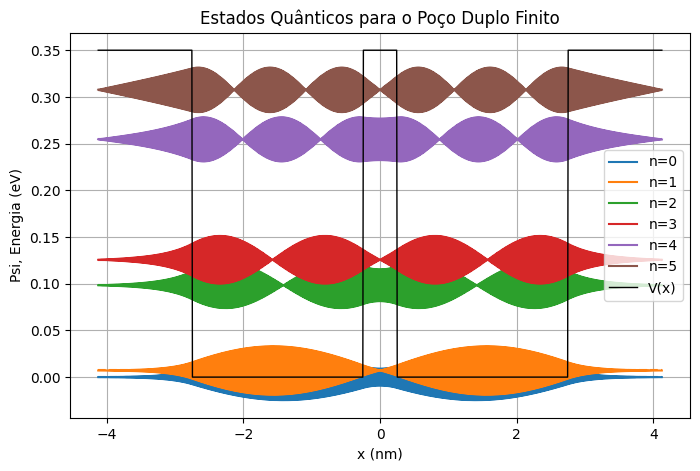

n = 0  ->  E = 0.000 eV
n = 1  ->  E = 0.007 eV
n = 2  ->  E = 0.098 eV
n = 3  ->  E = 0.126 eV
n = 4  ->  E = 0.255 eV
n = 5  ->  E = 0.308 eV


In [12]:
# ------------------- PLOT: Estados com linhas de energia e barreiras -------------------
plt.figure(figsize=(8, 5))
for n in range(num_estados):
    # Mantém referencial padronizado (todas as ondas 'para cima')
    if np.max(psi[:, n]) < np.abs(np.min(psi[:, n])):
        psi[:, n] *= -1
    # Linha horizontal representando energia
    plt.hlines(E[n]/eV, x[0]*1e9, x[-1]*1e9, colors='C'+str(n), linestyles='--')
    # Função de onda deslocada verticalmente para visualização        
    plt.plot(x*1e9, psi[:, n]*0.5 + E[n]/eV, label=f'n={n}')

# Potencial do poço
plt.plot(x*1e9, V/eV, 'k-', linewidth=1, label='V(x)')

plt.xlabel('x (nm)')
plt.ylabel('Psi, Energia (eV)')
plt.title('Estados Quânticos para o Poço Duplo Finito')
plt.legend(loc='center right')
plt.grid(True)
# Salvar figura 
plt.savefig("Resultados/estados_poco_duplo.png", dpi=300, bbox_inches='tight')
plt.show()


# ------------------- Mostrar energias -------------------
for n, En in enumerate(E):
    print(f"n = {n}  ->  E = {En/eV:.3f} eV")


Note que as autofunções plotadas representam versões unidimensionais de orbitais, sendo possível identificar seus nódulos. Ademais, note como estão "divididos em pares": é possível identificar as sobreposições simétricas e antissimétricas dos orbitais, sendo a antissimétrica a solução de maior energia dentre o par.

Os casos de energia mais próxima de $V_0$ representam um elétron próximo de estar livre, então a autofunção obtida para ele não é muito representativa devido à condição de contorno de Dirichlet.

## Referência

[1] DATTA, Supriyo. Quantum transport: atom to transistor. 1. ed. New York: Cambridge University Press, 2005.